# Dual Active Bridge (DAB) Converter — Design Notebook

This notebook covers the design and analysis of a **Dual Active Bridge (DAB)** DC-DC converter.

### Design Specifications

| Property | Symbol | Value | Unit |
|---|---|---|---|
| Nominal output power | $P_\mathrm{out,nom}$ | 50 | W |
| Nominal input voltage | $U_\mathrm{in,nom}$ | 50 | V |
| Minimum input voltage | $U_\mathrm{in,min}$ | 30 | V |
| Maximum input voltage | $U_\mathrm{in,max}$ | 60 | V |
| Output voltage | $U_\mathrm{out}$ | 15 | V |
| Output voltage ripple (rel.) | $\Delta U_\mathrm{out,pp,rel}$ | 2 | % |
| Switching frequency | $f_\mathrm{sw}$ | 40 | kHz |

In [7]:
import numpy as np
import matplotlib.pyplot as plt

## 1 — Design Specifications

In [8]:
# === Design Specifications ===
P_out_nom = 50          # Nominal output power [W]
U_in_nom  = 50          # Nominal input voltage [V]
U_in_min  = 30          # Minimum input voltage [V]
U_in_max  = 60          # Maximum input voltage [V]
U_out     = 12          # Output voltage [V]
dU_out_rel = 0.02       # Output voltage ripple (relative) [-]
f_sw      = 80e3        # Switching frequency [Hz]

# === Derived Quantities ===
T_sw      = 1 / f_sw                       # Switching period [s]
dU_out_pp = dU_out_rel * U_out             # Absolute output voltage ripple [V]

print(f"Switching period  T_sw  = {T_sw*1e6:.1f} µs")
print(f"Output ripple     ΔU_pp = {dU_out_pp*1e3:.0f} mV")

Switching period  T_sw  = 12.5 µs
Output ripple     ΔU_pp = 240 mV


## 2 — Transformer & Inductance

The turns ratio is chosen so that the reflected output voltage matches the nominal input:

$$n = \frac{U_\mathrm{in,nom}}{U_\mathrm{out}}$$

The DAB inductance $L$ is sized from the maximum power equation at nominal conditions with single-phase-shift modulation:

$$P_\mathrm{max} = \frac{n \, U_\mathrm{in} \, U_\mathrm{out}}{8 \, f_\mathrm{sw} \, L}$$

In [14]:
# Transformer turns ratio (voltage-matched at nominal input)
n = U_in_nom / U_out
print(f"Turns ratio  n = {n:.2f}")

# DAB inductance sized for nominal power at nominal input
# P = n * U_in_nom * U_out / (8 * f_sw * L)  =>  solve for L
# Safty margin P = 2* P_out_nom
safty_margin = 3
L = (n * U_in_nom * U_out) / (8 * f_sw * safty_margin * P_out_nom)
print(f"DAB inductance  L = {L*1e6:.2f} µH")

Turns ratio  n = 4.17
DAB inductance  L = 26.04 µH


## 3 — Maximum Output Power vs Input Voltage

Using the single-phase-shift (SPS) power transfer equation:

$$P_\mathrm{max}(U_\mathrm{in}) = \frac{n \, U_\mathrm{in} \, U_\mathrm{out}}{8 \, f_\mathrm{sw} \, L}$$

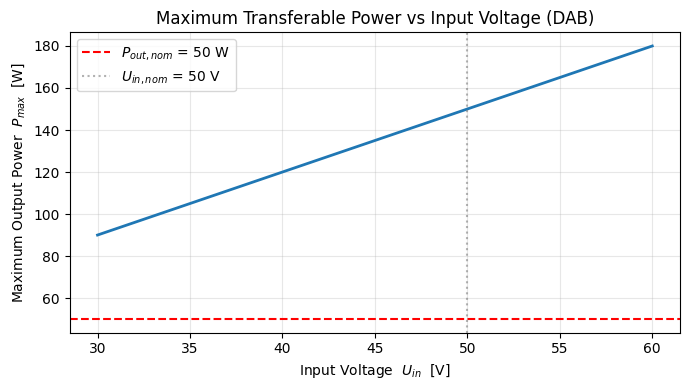

In [10]:
# Input voltage sweep
U_in = np.linspace(U_in_min, U_in_max, 300)

# Maximum transferable power
P_max = (n * U_in * U_out) / (8 * f_sw * L)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(U_in, P_max, linewidth=2)
ax.axhline(P_out_nom, color="r", linestyle="--", label=f"$P_{{out,nom}}$ = {P_out_nom} W")
ax.axvline(U_in_nom, color="gray", linestyle=":", alpha=0.6, label=f"$U_{{in,nom}}$ = {U_in_nom} V")
ax.set_xlabel("Input Voltage  $U_{in}$  [V]")
ax.set_ylabel("Maximum Output Power  $P_{max}$  [W]")
ax.set_title("Maximum Transferable Power vs Input Voltage (DAB)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 4 — Phase Shift for Nominal Power

The power transfer equation for single-phase-shift (SPS) modulation is:

$$P = \frac{n \, U_\mathrm{in} \, U_\mathrm{out} \, \phi \, (\pi - |\phi|)}{2 \pi^2 f_\mathrm{sw} \, L}$$

To find the phase shift $\phi$ required to deliver $P_\mathrm{out,nom}$ at a given $U_\mathrm{in}$, we rearrange into a quadratic in $\phi$ (for $\phi > 0$):

$$\phi^2 - \pi\,\phi + \frac{2\pi^2 f_\mathrm{sw} L \, P_\mathrm{out,nom}}{n \, U_\mathrm{in} \, U_\mathrm{out}} = 0$$

Solving (taking the smaller root for normal operation, $0 < \phi < \pi/2$):

$$\phi = \frac{\pi}{2}\left(1 - \sqrt{1 - \frac{8\,f_\mathrm{sw}\,L\,P_\mathrm{out,nom}}{n\,U_\mathrm{in}\,U_\mathrm{out}}}\right)$$

In [11]:
def phase_shift_for_power(P, U_in, U_out, n, f_sw, L):
    """
    Compute the SPS phase shift φ [rad] required to transfer power P.
    
    P = n * U_in * U_out * φ * (π - |φ|) / (2π² f_sw L)
    
    Returns the smaller root (normal operating region, 0 < φ < π/2).
    """
    discriminant = 1 - (8 * f_sw * L * P) / (n * U_in * U_out)
    if np.any(discriminant < 0):
        raise ValueError("Required power exceeds maximum transferable power for given U_in.")
    return (np.pi / 2) * (1 - np.sqrt(discriminant))


# --- Phase shifts at the three key operating points ---
phi_nom = phase_shift_for_power(P_out_nom, U_in_nom, U_out, n, f_sw, L)
phi_min = phase_shift_for_power(P_out_nom, U_in_min, U_out, n, f_sw, L)
phi_max = phase_shift_for_power(P_out_nom, U_in_max, U_out, n, f_sw, L)

print("Phase shifts to deliver P_out,nom = {:.0f} W:".format(P_out_nom))
print(f"  φ(U_in,min = {U_in_min} V) = {phi_min:.4f} rad  = {np.degrees(phi_min):.2f}°")
print(f"  φ(U_in,nom = {U_in_nom} V) = {phi_nom:.4f} rad  = {np.degrees(phi_nom):.2f}°")
print(f"  φ(U_in,max = {U_in_max} V) = {phi_max:.4f} rad  = {np.degrees(phi_max):.2f}°")

Phase shifts to deliver P_out,nom = 50 W:
  φ(U_in,min = 30 V) = 0.5236 rad  = 30.00°
  φ(U_in,nom = 50 V) = 0.2882 rad  = 16.52°
  φ(U_in,max = 60 V) = 0.2359 rad  = 13.51°


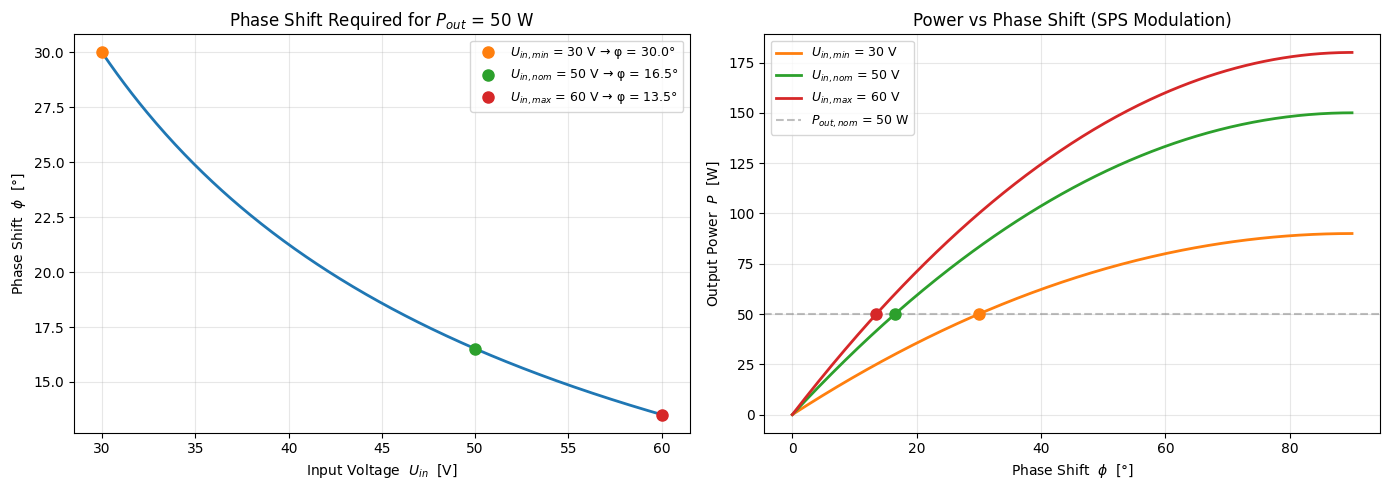

In [12]:
# --- Phase shift vs Input Voltage (at P = P_out,nom) ---
U_in_sweep = np.linspace(U_in_min, U_in_max, 300)
phi_sweep  = phase_shift_for_power(P_out_nom, U_in_sweep, U_out, n, f_sw, L)

# --- Power vs Phase shift (at the three key voltages) ---
phi_range = np.linspace(0, np.pi/2, 300)

P_at_Vmin = (n * U_in_min * U_out * phi_range * (np.pi - phi_range)) / (2 * np.pi**2 * f_sw * L)
P_at_Vnom = (n * U_in_nom * U_out * phi_range * (np.pi - phi_range)) / (2 * np.pi**2 * f_sw * L)
P_at_Vmax = (n * U_in_max * U_out * phi_range * (np.pi - phi_range)) / (2 * np.pi**2 * f_sw * L)

# ===================== PLOTS =====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Phase shift required vs U_in ---
ax1 = axes[0]
ax1.plot(U_in_sweep, np.degrees(phi_sweep), linewidth=2, color="tab:blue")

# Mark the three key operating points
for U, phi, color, label in [
    (U_in_min, phi_min, "tab:orange", f"$U_{{in,min}}$ = {U_in_min} V → φ = {np.degrees(phi_min):.1f}°"),
    (U_in_nom, phi_nom, "tab:green",  f"$U_{{in,nom}}$ = {U_in_nom} V → φ = {np.degrees(phi_nom):.1f}°"),
    (U_in_max, phi_max, "tab:red",    f"$U_{{in,max}}$ = {U_in_max} V → φ = {np.degrees(phi_max):.1f}°"),
]:
    ax1.plot(U, np.degrees(phi), "o", color=color, markersize=8, zorder=5, label=label)

ax1.set_xlabel("Input Voltage  $U_{in}$  [V]")
ax1.set_ylabel("Phase Shift  $\\phi$  [°]")
ax1.set_title(f"Phase Shift Required for $P_{{out}}$ = {P_out_nom} W")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Right: Power vs Phase shift at each key voltage ---
ax2 = axes[1]
ax2.plot(np.degrees(phi_range), P_at_Vmin, linewidth=2, color="tab:orange", label=f"$U_{{in,min}}$ = {U_in_min} V")
ax2.plot(np.degrees(phi_range), P_at_Vnom, linewidth=2, color="tab:green",  label=f"$U_{{in,nom}}$ = {U_in_nom} V")
ax2.plot(np.degrees(phi_range), P_at_Vmax, linewidth=2, color="tab:red",    label=f"$U_{{in,max}}$ = {U_in_max} V")

# Mark operating points
ax2.plot(np.degrees(phi_min), P_out_nom, "o", color="tab:orange", markersize=8, zorder=5)
ax2.plot(np.degrees(phi_nom), P_out_nom, "o", color="tab:green",  markersize=8, zorder=5)
ax2.plot(np.degrees(phi_max), P_out_nom, "o", color="tab:red",    markersize=8, zorder=5)

ax2.axhline(P_out_nom, color="gray", linestyle="--", alpha=0.5, label=f"$P_{{out,nom}}$ = {P_out_nom} W")

ax2.set_xlabel("Phase Shift  $\\phi$  [°]")
ax2.set_ylabel("Output Power  $P$  [W]")
ax2.set_title("Power vs Phase Shift (SPS Modulation)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()